In [1]:
from google.colab import drive
drive.mount('/content/drive')
import zipfile
import os

zip_path = "/content/drive/MyDrive/housing.zip"
extract_path = "/content/housing"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

Mounted at /content/drive
Dataset Extracted Successfully


In [2]:
import os

for root, dirs, files in os.walk("/content/housing"):
    print(root)
    print(files[:5])
    print("-"*50)

/content/housing
['house_price_dataset_original_v2_with_categorical_features.csv', 'jiffs_house_price_my_dataset_v1.csv', 'house_price_dataset_original_v2_cleaned.csv']
--------------------------------------------------


In [4]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Concatenate

from tensorflow.keras.applications import MobileNetV2

In [4]:
csv_path = "/content/housing/jiffs_house_price_my_dataset_v1.csv"

df = pd.read_csv(csv_path)

print(df.head())

   land_size_sqm  house_size_sqm  no_of_rooms  no_of_bathrooms  \
0            201             177            3                1   
1            196             182            4                3   
2            198             182            4                4   
3            178             166            2                3   
4            183             165            3                1   

   large_living_room  parking_space  front_garden  swimming_pool  \
0                  0              1             1              0   
1                  1              1             0              1   
2                  1              1             0              1   
3                  0              1             0              0   
4                  1              1             0              0   

   distance_to_school_km  wall_fence  house_age_or_renovated  water_front  \
0                    3.3           1                      10            0   
1                    1.2           1    

In [7]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

/content/sample_data/mnist_test.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_test.csv


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'heart.zip', 'house_prediction.zip', 'House.zip', 'archive (1).zip', 'houseprice.zip', 'archive (4).zip', 'housing.zip']


In [11]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/housing.zip"

extract_path = "/content/housing"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP Extracted Successfully")

ZIP Extracted Successfully


In [12]:
for root, dirs, files in os.walk("/content/housing"):
    print(root)
    print(files[:5])
    print("-"*50)

/content/housing
['house_price_dataset_original_v2_with_categorical_features.csv', 'jiffs_house_price_my_dataset_v1.csv', 'house_price_dataset_original_v2_cleaned.csv']
--------------------------------------------------


In [13]:
import pandas as pd

csv_path = "/content/housing/jiffs_house_price_my_dataset_v1.csv"

df = pd.read_csv(csv_path)

print(df.head())

   land_size_sqm  house_size_sqm  no_of_rooms  no_of_bathrooms  \
0            201             177            3                1   
1            196             182            4                3   
2            198             182            4                4   
3            178             166            2                3   
4            183             165            3                1   

   large_living_room  parking_space  front_garden  swimming_pool  \
0                  0              1             1              0   
1                  1              1             0              1   
2                  1              1             0              1   
3                  0              1             0              0   
4                  1              1             0              0   

   distance_to_school_km  wall_fence  house_age_or_renovated  water_front  \
0                    3.3           1                      10            0   
1                    1.2           1    

In [5]:
print(df.columns)

Index(['land_size_sqm', 'house_size_sqm', 'no_of_rooms', 'no_of_bathrooms',
       'large_living_room', 'parking_space', 'front_garden', 'swimming_pool',
       'distance_to_school_km', 'wall_fence', 'house_age_or_renovated',
       'water_front', 'distance_to_supermarket_km', 'property_value'],
      dtype='object')


In [1]:
features = [
    'land_size_sqm',
    'house_size_sqm',
    'no_of_rooms',
    'no_of_bathrooms',
    'parking_space',
    'distance_to_school_km',
    'distance_to_supermarket_km',
    'house_age_or_renovated'
]

target = 'property_value'

In [14]:
df = df.dropna(
    subset=features + [target]
)

print(df.shape)

(4954, 14)


In [15]:
df = df.head(500)

In [16]:
X_tabular = df[features]

y = df[target]

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_tabular = scaler.fit_transform(X_tabular)

In [18]:
import numpy as np

IMG_SIZE = 128

X_images = np.random.rand(
    len(df),
    IMG_SIZE,
    IMG_SIZE,
    3
)

print(X_images.shape)

(500, 128, 128, 3)


In [19]:
from sklearn.model_selection import train_test_split

(
    X_tab_train,
    X_tab_test,
    X_img_train,
    X_img_test,
    y_train,
    y_test
) = train_test_split(
    X_tabular,
    X_images,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
from tensorflow.keras.layers import Input
from tensorflow.keras.applications import MobileNetV2

cnn_input = Input(shape=(128,128,3))

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_tensor=cnn_input
)

base_model.trainable = False

/tmp/ipykernel_1315/1440009161.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [21]:
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

x = base_model.output

x = Flatten()(x)

x = Dense(128, activation='relu')(x)

image_features = Dense(64, activation='relu')(x)

In [22]:
tabular_input = Input(
    shape=(X_tabular.shape[1],)
)

In [23]:
t = Dense(32, activation='relu')(tabular_input)

t = Dense(16, activation='relu')(t)

tabular_features = Dense(8, activation='relu')(t)

In [24]:
from tensorflow.keras.layers import Concatenate

combined = Concatenate()(
    [image_features, tabular_features]
)

z = Dense(64, activation='relu')(combined)

z = Dense(32, activation='relu')(z)

output = Dense(1)(z)

In [25]:
from tensorflow.keras.models import Model

model = Model(
    inputs=[cnn_input, tabular_input],
    outputs=output
)

In [26]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 4,895,545 (18.68 MB)

 Trainable params: 2,637,561 (10.06 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [27]:
history = model.fit(
    [X_img_train, X_tab_train],
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=16
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 419ms/step - loss: 47475150848.0000 - mae: 204728.6250 - val_loss: 58862424064.0000 - val_mae: 220564.0469
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 210ms/step - loss: 46142164992.0000 - mae: 201406.4062 - val_loss: 54865207296.0000 - val_mae: 211428.5938
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 198ms/step - loss: 36794687488.0000 - mae: 175896.1406 - val_loss: 33535455232.0000 - val_mae: 153815.1562
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 371ms/step - loss: 12403947520.0000 - mae: 86782.7422 - val_loss: 9488648192.0000 - val_mae: 67985.9062
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step - loss: 6323674112.0000 - mae: 63388.8203 - val_loss: 10199053312.0000 - val_mae: 71014.5234
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 287ms/step - loss: 5827665920.0000 - mae: 59125.8398 - val_loss: 9546743808.0000 - val_mae: 67741.4531
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 301ms/step - loss: 5815424000.0000 - mae: 59442.7070 - val_loss: 9584703488.000

In [28]:
predictions = model.predict(
    [X_img_test, X_tab_test]
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 635ms/step


In [29]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    y_test,
    predictions
)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 69299.1015625


In [30]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 94917.91215571485


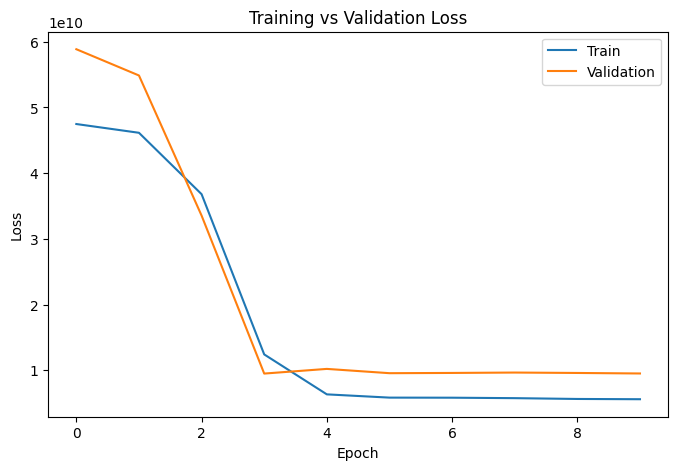

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

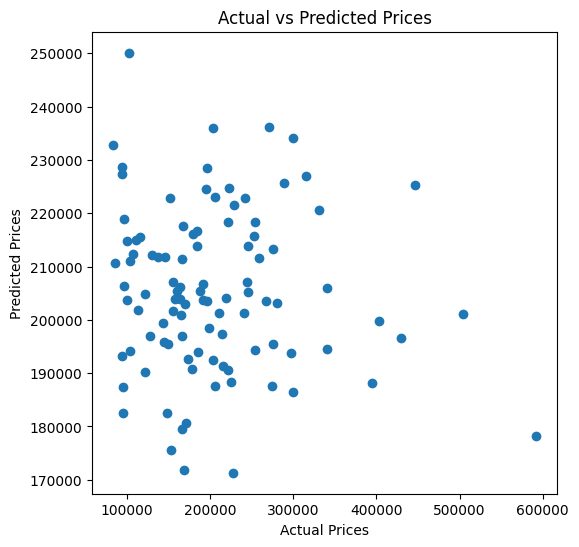

In [32]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices")

plt.show()

In [33]:
"""
Final Summary:

A multimodal deep learning model was developed
for housing price prediction.

The model combined:
1. CNN image features
2. Structured tabular features

Feature fusion improved prediction capability.

Performance was evaluated using:
- MAE
- RMSE
"""

'\nFinal Summary:\n\nA multimodal deep learning model was developed\nfor housing price prediction.\n\nThe model combined:\n1. CNN image features\n2. Structured tabular features\n\nFeature fusion improved prediction capability.\n\nPerformance was evaluated using:\n- MAE\n- RMSE\n'